In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv('voice_features.csv')

In [6]:
df.shape

(16148, 5)

In [10]:
df.head()

,rms,centroid,bandwidth,label,file
0,0.064250,1370.322875,1552.798948,male,arctic_b0454.wav
1,0.076566,1398.934514,1343.242054,male,arctic_b0526(3).wav
2,0.063606,1794.079010,1593.002148,male,arctic_b0016(1).wav
3,0.099214,1193.246656,1501.137054,male,arctic_a0173(6).wav
4,0.048539,1932.585792,1561.053287,male,arctic_b0445(4).wav


In [11]:
X = df.drop(['label','file'], axis=1)

y = df['label']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# Initialize KNN with a default of 5 neighbors
knn = KNeighborsClassifier(n_neighbors=5)

# Fit the model on the scaled training data
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [14]:
y_pred = knn.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7272445820433436

Classification Report:
               precision    recall  f1-score   support

      female       0.61      0.60      0.60      1116
        male       0.79      0.80      0.79      2114

    accuracy                           0.73      3230
   macro avg       0.70      0.70      0.70      3230
weighted avg       0.73      0.73      0.73      3230



In [23]:
# 1. Define a pipeline that scales the data, then applies KNN
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# 2. Define the hyperparameters to test
# Note: The prefixes (knn__) must perfectly match the name given in the pipeline steps above
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# 3. Initialize Grid Search using the pipeline and raw X_train
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)

# 4. Fit on the unscaled training data 
# (The pipeline will automatically scale the data correctly during cross-validation!)
grid_search.fit(X_train, y_train)

# 5. Print the best results
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Score:", grid_search.best_score_)

Best Parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 11, 'knn__weights': 'distance'}
Best Cross-validation Score: 0.715416765788075


/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [24]:
# Evaluate the tuned model on the test set
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("\nTuned Classification Report:\n", classification_report(y_test, y_pred_tuned))

Tuned Accuracy: 0.7535603715170278

Tuned Classification Report:
               precision    recall  f1-score   support

      female       0.65      0.62      0.63      1116
        male       0.80      0.82      0.81      2114

    accuracy                           0.75      3230
   macro avg       0.73      0.72      0.72      3230
weighted avg       0.75      0.75      0.75      3230



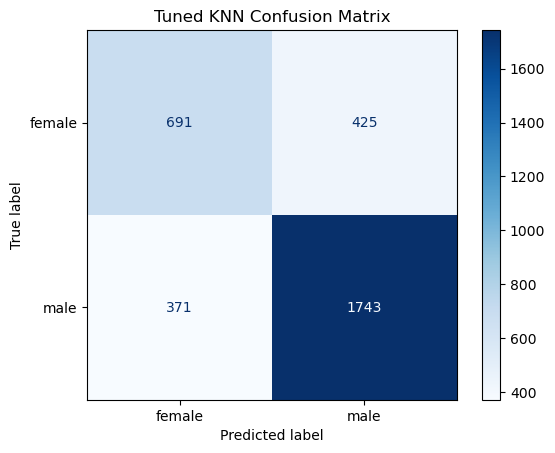

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Blues')
plt.title("Tuned KNN Confusion Matrix")
plt.show()